In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

# Load the dataset from Google Drive
data = pd.read_csv('/content/drive/MyDrive/creditcard.csv')
print(f"Dataset loaded successfully! Shape: {data.shape}")
data.head()

Dataset loaded successfully! Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Basic Exploratory Data Analysis (EDA)

print(f"Total transactions: {len(data)}")
print(f"\nFraud vs Normal breakdown:")
print(data['Class'].value_counts().rename({0: 'Normal', 1: 'Fraud'}))
print(f"\nFraud percentage: {data['Class'].mean() * 100:.2f}%")

Total transactions: 284807

Fraud vs Normal breakdown:
Class
Normal    284315
Fraud        492
Name: count, dtype: int64

Fraud percentage: 0.17%


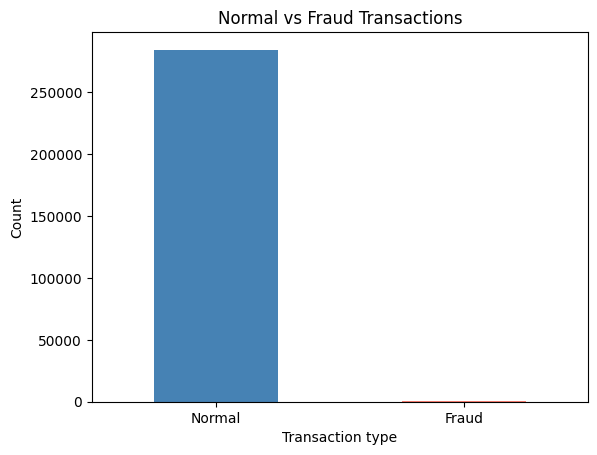

In [6]:
import matplotlib.pyplot as plt

data['Class'].value_counts().rename({0: 'Normal', 1: 'Fraud'}).plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Normal vs Fraud Transactions')
plt.xlabel('Transaction type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [7]:
# Check for missing values

missing = data.isnull().sum()
total_missing = missing.sum()

print(f"Total missing values: {total_missing}")
if total_missing > 0:
    print("\nMissing values per column:")
    print(missing[missing > 0])
else:
    print("No missing values found in the dataset.")

Total missing values: 0
No missing values found in the dataset.


In [8]:
# Prepare data for model training

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

if 'id' in data.columns:
    data = data.drop('id', axis=1)

X = data.drop('Class', axis=1)
y = data['Class']



# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Before SMOTE:")
print(y_train.value_counts())

# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train).value_counts())

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

print(f"\nFraud in train: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Fraud in test:  {y_test.sum()} ({y_test.mean()*100:.2f}%)")

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

Training set: 454902 samples
Test set:     56962 samples

Fraud in train: 227451 (50.00%)
Fraud in test:  98 (0.17%)


In [9]:
# Train ML model: Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(max_iter=2000, random_state=42)

# Train model
lr_model.fit(X_train, y_train)

# Predictions
train_preds = lr_model.predict(X_train)
test_preds = lr_model.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, test_preds)

print("=== Logistic Regression Results ===")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Testing Accuracy:  {test_accuracy*100:.2f}%\n")

print("Classification Report (Test Data):")
print(classification_report(y_test, test_preds, target_names=['Normal', 'Fraud']))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression Results ===
Training Accuracy: 97.87%
Testing Accuracy:  98.82%

Classification Report (Test Data):
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     56864
       Fraud       0.12      0.91      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.95      0.60     56962
weighted avg       1.00      0.99      0.99     56962



In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_preds)

print("=== Random Forest Results ===")
print(f"Testing Accuracy: {rf_accuracy*100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, rf_preds, target_names=['Normal', 'Fraud']))

=== Random Forest Results ===
Testing Accuracy: 99.84%

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.52      0.89      0.66        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962




=== Model Comparison ===
           Logistic Regression  Random Forest
Metric                                       
Accuracy              0.988238       0.998420
Precision             0.118667       0.524096
Recall                0.908163       0.887755
F1 Score              0.209906       0.659091


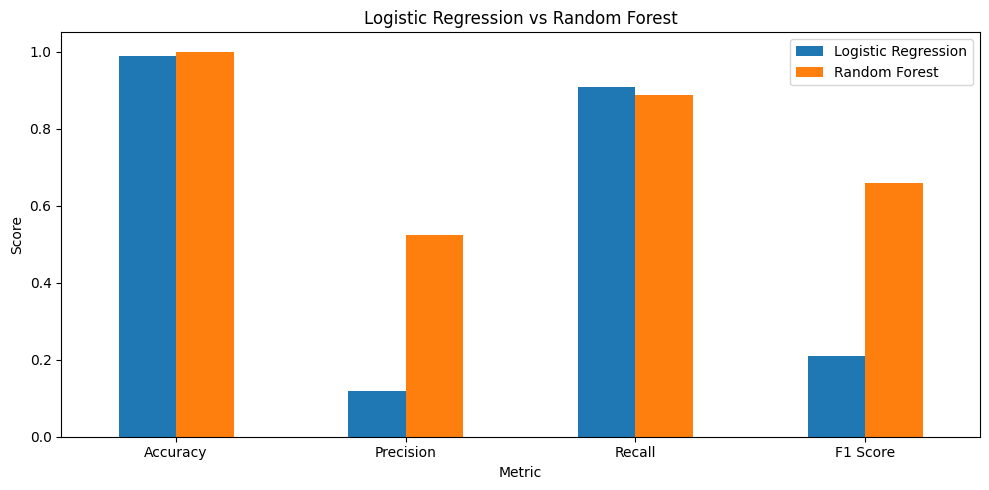

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression predictions
lr_preds = lr_model.predict(X_test)

# Random Forest predictions
rf_preds = rf_model.predict(X_test)

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': [
        accuracy_score(y_test, lr_preds),
        precision_score(y_test, lr_preds),
        recall_score(y_test, lr_preds),
        f1_score(y_test, lr_preds)
    ],
    'Random Forest': [
        accuracy_score(y_test, rf_preds),
        precision_score(y_test, rf_preds),
        recall_score(y_test, rf_preds),
        f1_score(y_test, rf_preds)
    ]
})

results.set_index('Metric', inplace=True)

print("\n=== Model Comparison ===")
print(results.to_string())

# Plot comparison
results.plot(kind='bar', figsize=(10,5))
plt.title("Logistic Regression vs Random Forest")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1.05)
plt.tight_layout()
plt.show()

## Summary

Two machine learning models, **Logistic Regression** and **Random Forest**, were evaluated for fraud detection using accuracy, precision, recall, and F1-score.

The results show that Random Forest performs better overall. It achieved a higher accuracy **(99.84%)** compared to Logistic Regression** (98.82%)**, meaning it correctly classifies more transactions. Random Forest also has a much higher precision **(52.41%)**, indicating that when the model predicts a transaction as fraud, it is more likely to be correct. In contrast, Logistic Regression has very low precision** (11.87%)**, which means it produces many false fraud alerts.

Although Logistic Regression has slightly higher recall (90.82%), meaning it detects slightly more fraud cases, its overall effectiveness is limited because it incorrectly flags many normal transactions as fraud. The F1-score, which balances precision and recall, is significantly higher for Random Forest (0.66) than for Logistic Regression (0.21).

**Conclusion:**
**Random Forest **is the **better model **for fraud detection because it provides higher accuracy, much better precision, and a stronger balance between detecting fraud and minimizing false alarms.